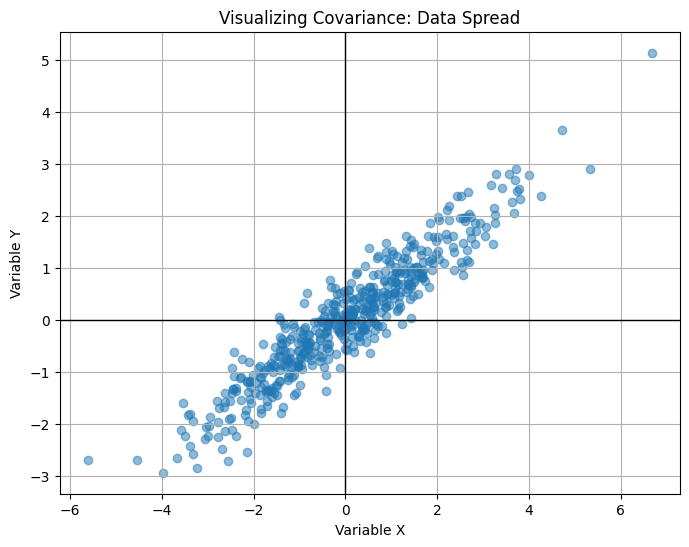

설정된 공분산 행렬:
 [[3.  2. ]
 [2.  1.5]]


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 무작위 데이터 생성
np.random.seed(42)
data = np.random.randn(2, 500)

# 2. 공분산 행렬 설정 (데이터를 특정 방향으로 늘리기 위함)
# [[x축 분산, 공분산], [공분산, y축 분산]]
cov_matrix = np.array([[3, 2], [2, 1.5]])

# 3. 촐레스키 분해 등을 이용해 데이터에 상관관계 주입
# (공분산 행렬을 통해 데이터의 형태를 변환하는 과정)
L = np.linalg.cholesky(cov_matrix)
transformed_data = L @ data

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(transformed_data[0, :], transformed_data[1, :], alpha=0.5)
plt.title("Visualizing Covariance: Data Spread")
plt.xlabel("Variable X")
plt.ylabel("Variable Y")
plt.grid(True)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.show()

print("설정된 공분산 행렬:\n", cov_matrix)

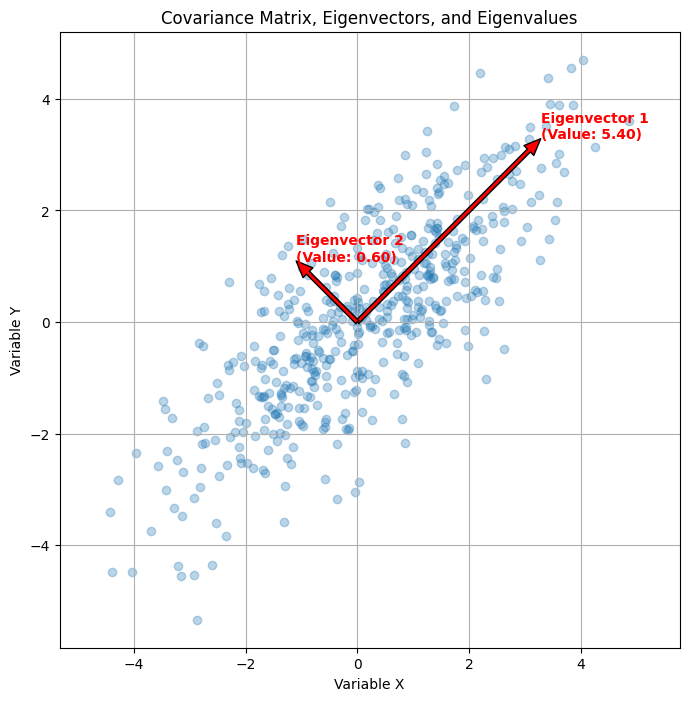

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 생성 (우상향하는 타원형 데이터)
np.random.seed(0)
mean = [0, 0]
cov = [[3, 2.4], [2.4, 3]]  # 공분산 행렬
data = np.random.multivariate_normal(mean, cov, 500).T

# 2. 고유값과 고유벡터 계산
eigenvalues, eigenvectors = np.linalg.eig(cov)

# 3. 시각화
plt.figure(figsize=(8, 8))
plt.scatter(data[0, :], data[1, :], alpha=0.3, label='Data points')

# 고유벡터 그리기 (고유값을 곱해 길이를 조절함)
for i in range(len(eigenvalues)):
    # 고유벡터 방향으로 고유값만큼 화살표 표시
    v = eigenvectors[:, i] * np.sqrt(eigenvalues[i]) * 2 
    plt.annotate('', xy=v, xytext=(0, 0),
                 arrowprops=dict(facecolor='red', width=3, headwidth=10))
    plt.text(v[0], v[1], f'Eigenvector {i+1}\n(Value: {eigenvalues[i]:.2f})', 
             color='red', fontweight='bold')

plt.title("Covariance Matrix, Eigenvectors, and Eigenvalues")
plt.xlabel("Variable X")
plt.ylabel("Variable Y")
plt.axis('equal')
plt.grid(True)
plt.show()